<a href="https://colab.research.google.com/github/sanidhya2506/Alzheimers_Cascading_Multimodal/blob/main/Alzheimers_Cascading_Multimodal_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage1**

In [ ]:
import kagglehub
import os
import pandas as pd

# Download the dataset using kagglehub
path = kagglehub.dataset_download("veeresh04/adnimerge")
print("Path to dataset files:", path)

# Find the CSV file inside the downloaded path
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, csv_files[0])
print(f"Loading file from: {file_path}")

100%|██████████| 1.76M/1.76M [00:00<00:00, 95.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/veeresh04/adnimerge/versions/1
Loading file from: /root/.cache/kagglehub/datasets/veeresh04/adnimerge/versions/1/ADNIMERGE_05Mar2026.csv


In [ ]:
# Load the dataset
df = pd.read_csv(file_path, low_memory=False)

# Filter for baseline visits only
df_bl = df[df['VISCODE'] == 'bl'].copy()

print(f"Total baseline patients loaded: {len(df_bl)}")

Total baseline patients loaded: 2430


In [ ]:
# Stage 1: Initial Cognitive Screening & Baseline Clinical Data
stage_1_cols = ['PTID', 'AGE', 'PTGENDER', 'MMSE', 'MOCA', 'CDRSB', 'DX_bl']

# Stage 2: Blood-Based Biomarkers & Risk Factors
stage_2_cols = ['APOE4', 'ABETA', 'TAU', 'PTAU']

# Stage 3: Structural Brain MRI Metrics
stage_3_cols = ['Hippocampus', 'WholeBrain', 'Ventricles', 'Entorhinal', 'ICV']

# Stage 4: PET Scan Biomarkers (Advanced Confirmation)
stage_4_cols = ['FDG', 'AV45']

# Create master dataframe with target diagnosis
selected_cols = list(set(stage_1_cols + stage_2_cols + stage_3_cols + stage_4_cols))
df_model = df_bl[selected_cols].copy()

# Inspect missing values and preview data
print(df_model.info())
df_model.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2430 entries, 0 to 16408
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TAU          1215 non-null   object 
 1   Hippocampus  2081 non-null   float64
 2   MMSE         2429 non-null   float64
 3   ICV          2338 non-null   float64
 4   AV45         1133 non-null   float64
 5   FDG          1515 non-null   float64
 6   Entorhinal   2052 non-null   float64
 7   MOCA         1573 non-null   float64
 8   PTID         2430 non-null   object 
 9   APOE4        2213 non-null   float64
 10  ABETA        1215 non-null   object 
 11  Ventricles   2252 non-null   float64
 12  DX_bl        2419 non-null   object 
 13  PTGENDER     2430 non-null   object 
 14  WholeBrain   2292 non-null   float64
 15  PTAU         1215 non-null   object 
 16  CDRSB        2430 non-null   float64
 17  AGE          2426 non-null   float64
dtypes: float64(12), object(6)
memory usage: 360.7+ KB
No

,TAU,Hippocampus,MMSE,ICV,AV45,FDG,Entorhinal,MOCA,PTID,APOE4,ABETA,Ventricles,DX_bl,PTGENDER,WholeBrain,PTAU,CDRSB,AGE
0,NaN,8336.0,28.0,1984660.0,NaN,1.33615,4177.0,NaN,011_S_0002,0.0,NaN,118233.0,CN,Male,1229740.0,NaN,0.0,74.3
1,239.7,5319.0,20.0,1920690.0,NaN,1.10860,1791.0,NaN,011_S_0003,1.0,741.5,84599.0,AD,Male,1129830.0,22.83,4.5,81.3
5,153.1,6869.0,27.0,1679440.0,NaN,NaN,3983.0,NaN,022_S_0004,0.0,1501,39605.0,LMCI,Male,1154980.0,13.29,1.0,67.5
10,337,7075.0,29.0,1640770.0,NaN,1.25956,4433.0,NaN,011_S_0005,0.0,547.3,34062.0,CN,Male,1116630.0,33.43,0.0,73.7
15,NaN,5348.0,25.0,1485830.0,NaN,NaN,2277.0,NaN,100_S_0006,0.0,NaN,39826.0,LMCI,Female,927510.0,NaN,0.5,80.4


### STEP 1: DATA CLEANING & PREPROCESSING

#### Handle Target Column (`DX_bl` and `High_Risk`)

In [ ]:
import numpy as np

# Drop rows where DX_bl is missing
df_model.dropna(subset=['DX_bl'], inplace=True)

# Map diagnosis categories into a numeric classification target
dx_mapping = {
    'CN': 0, # Cognitively Normal
    'LMCI': 1, # Late Mild Cognitive Impairment
    'EMCI': 1, # Early Mild Cognitive Impairment
    'MCI': 1, # Mild Cognitive Impairment
    'AD': 2  # Alzheimer's Disease
}
df_model['DX_bl_numeric'] = df_model['DX_bl'].replace(dx_mapping)

# Create a binary high-risk target column 'High_Risk'
df_model['High_Risk'] = df_model['DX_bl_numeric'].apply(lambda x: 0 if x == 0 else 1)

print(f"Shape after dropping missing DX_bl: {df_model.shape}")
display(df_model[['DX_bl', 'DX_bl_numeric', 'High_Risk']].value_counts().reset_index(name='count'))

Shape after dropping missing DX_bl: (2419, 20)


,DX_bl,DX_bl_numeric,High_Risk,count
0,LMCI,1,1,690
1,CN,0,0,542
2,EMCI,1,1,423
3,AD,2,1,411
4,SMC,SMC,1,353


#### Clean Data Types

In [ ]:
# Convert PTGENDER to binary numeric values
df_model['PTGENDER'] = df_model['PTGENDER'].map({'Male': 1, 'Female': 0})

# Convert string biomarker columns (ABETA, TAU, PTAU) into numeric float64
# Remove any non-numeric symbols like '<' or '>'
for col in ['ABETA', 'TAU', 'PTAU']:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.replace('<', '', regex=False).str.replace('>', '', regex=False)
        # Convert to numeric, coercing errors will turn invalid parsing into NaN
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

print("Data types after cleaning:")
display(df_model[['PTGENDER', 'ABETA', 'TAU', 'PTAU']].dtypes)

Data types after cleaning:


,0
PTGENDER,int64
ABETA,float64
TAU,float64
PTAU,float64


#### Missing Value Analysis

In [ ]:
# Show missing data percentages for each column
missing_percentage = df_model.isnull().sum() / len(df_model) * 100
missing_info = pd.DataFrame({
    'Missing Count': df_model.isnull().sum(),
    'Missing Percentage': missing_percentage
})
print("Missing Value Information:")
display(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

Missing Value Information:


,Missing Count,Missing Percentage
AV45,1287,53.203803
TAU,1204,49.772633
PTAU,1204,49.772633
ABETA,1204,49.772633
FDG,906,37.453493
MOCA,853,35.262505
Entorhinal,374,15.460934
Hippocampus,345,14.262092
APOE4,209,8.639934
Ventricles,174,7.193055


#### Data Imputation
Perform `KNNImputer` or `SimpleImputer(strategy='median')` on all numerical features. `PTID` will be excluded from imputation as it's an identifier.

In [ ]:
from sklearn.impute import KNNImputer, SimpleImputer

# Identify numerical columns for imputation, excluding 'PTID', and target columns
numeric_cols = df_model.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['PTID', 'DX_bl_numeric', 'High_Risk']]

# Using KNNImputer as it generally performs better than SimpleImputer for complex datasets
# If a column has too many missing values or is not suitable for KNN, SimpleImputer can be an alternative.
# For demonstration, we'll use KNNImputer.
imputer = KNNImputer(n_neighbors=5)

# Create a copy to store imputed data
df_imputed = df_model.copy()

df_imputed[numeric_cols] = imputer.fit_transform(df_imputed[numeric_cols])

print("Missing values after imputation:")
print(df_imputed[numeric_cols].isnull().sum().sum())

display(df_imputed.head())

Missing values after imputation:
0


,TAU,Hippocampus,MMSE,ICV,AV45,FDG,Entorhinal,MOCA,PTID,APOE4,ABETA,Ventricles,DX_bl,PTGENDER,WholeBrain,PTAU,CDRSB,AGE,DX_bl_numeric,High_Risk
0,267.50,8336.0,28.0,1984660.0,1.12580,1.336150,4177.0,25.4,011_S_0002,0.0,1024.60,118233.0,CN,1.0,1229740.0,24.556,0.0,74.3,0,0
1,239.70,5319.0,20.0,1920690.0,1.39386,1.108600,1791.0,20.8,011_S_0003,1.0,741.50,84599.0,AD,1.0,1129830.0,22.830,4.5,81.3,2,1
5,153.10,6869.0,27.0,1679440.0,1.04648,1.218746,3983.0,23.0,022_S_0004,0.0,1501.00,39605.0,LMCI,1.0,1154980.0,13.290,1.0,67.5,1,1
10,337.00,7075.0,29.0,1640770.0,1.12580,1.259560,4433.0,26.4,011_S_0005,0.0,547.30,34062.0,CN,1.0,1116630.0,33.430,0.0,73.7,0,0
15,328.08,5348.0,25.0,1485830.0,1.35480,1.206334,2277.0,20.8,100_S_0006,0.0,972.48,39826.0,LMCI,0.0,927510.0,31.792,0.5,80.4,1,1


### STEP 2: EXPLORATORY DATA ANALYSIS (EDA)

#### Class Distribution of `DX_bl_numeric` and `High_Risk`

/tmp/ipykernel_800/2330526712.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DX_bl_numeric', data=df_imputed, palette='viridis')
/tmp/ipykernel_800/2330526712.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='High_Risk', data=df_imputed, palette='magma')


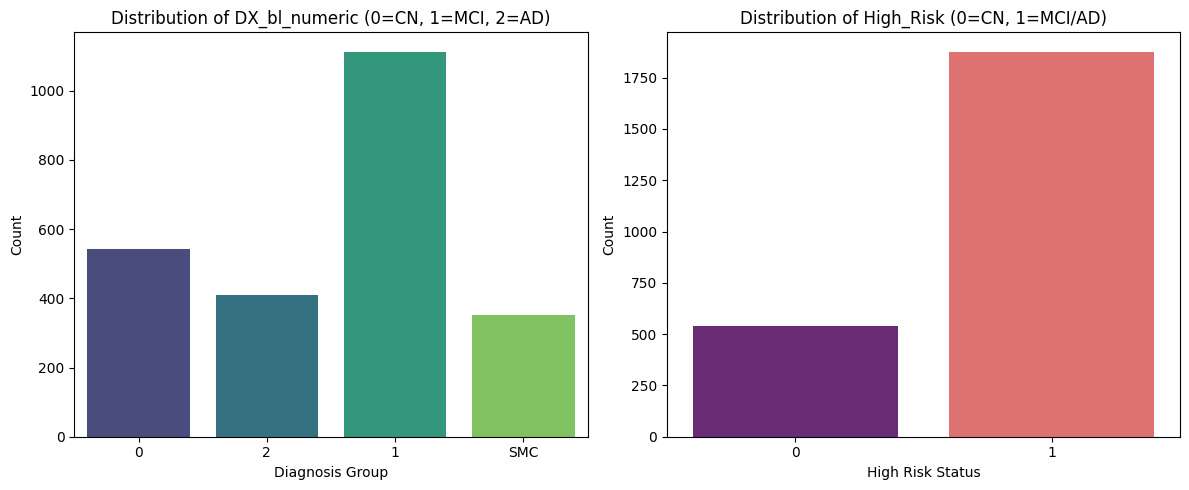

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='DX_bl_numeric', data=df_imputed, palette='viridis')
plt.title('Distribution of DX_bl_numeric (0=CN, 1=MCI, 2=AD)')
plt.xlabel('Diagnosis Group')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='High_Risk', data=df_imputed, palette='magma')
plt.title('Distribution of High_Risk (0=CN, 1=MCI/AD)')
plt.xlabel('High Risk Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

#### Correlation Heatmap of Stage 1 Cognitive Scores vs. AGE and Target

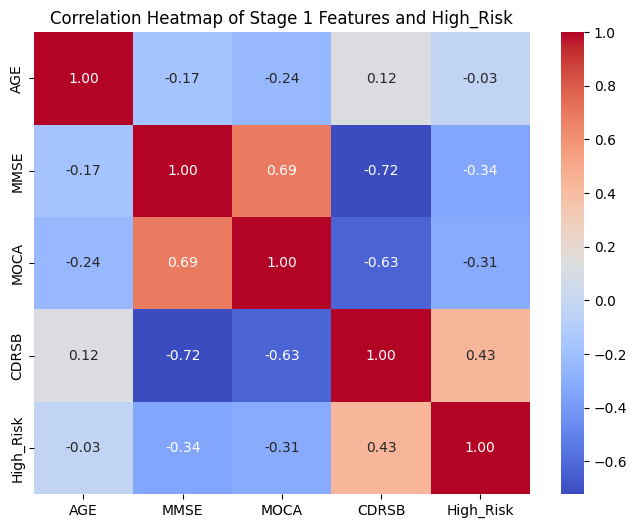

In [ ]:
stage1_corr_cols = ['AGE', 'MMSE', 'MOCA', 'CDRSB', 'High_Risk']
corr_matrix = df_imputed[stage1_corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Stage 1 Features and High_Risk')
plt.show()

#### Missingness Heatmap or Bar Plot Across Stage 1 to Stage 4 Columns
Since imputation has already been performed, this plot will show no missing values if the imputation was complete. However, it's useful to visualize the *original* missingness for context if needed, but for the current state (`df_imputed`), this will confirm completeness.

Missingness before imputation:


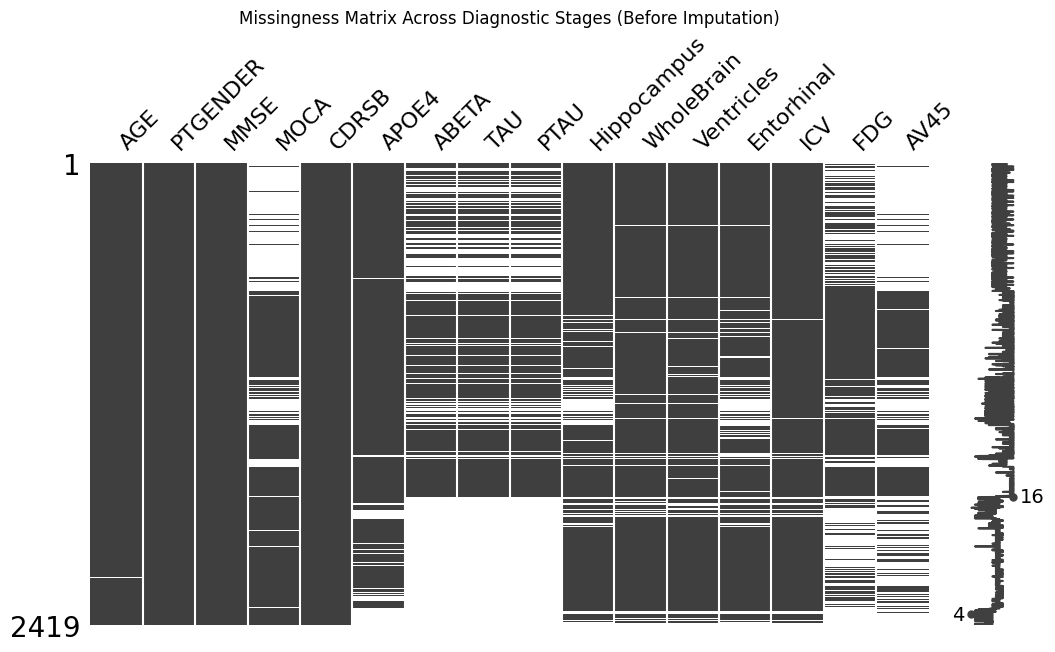

Missingness after imputation (should be none for numerical features):


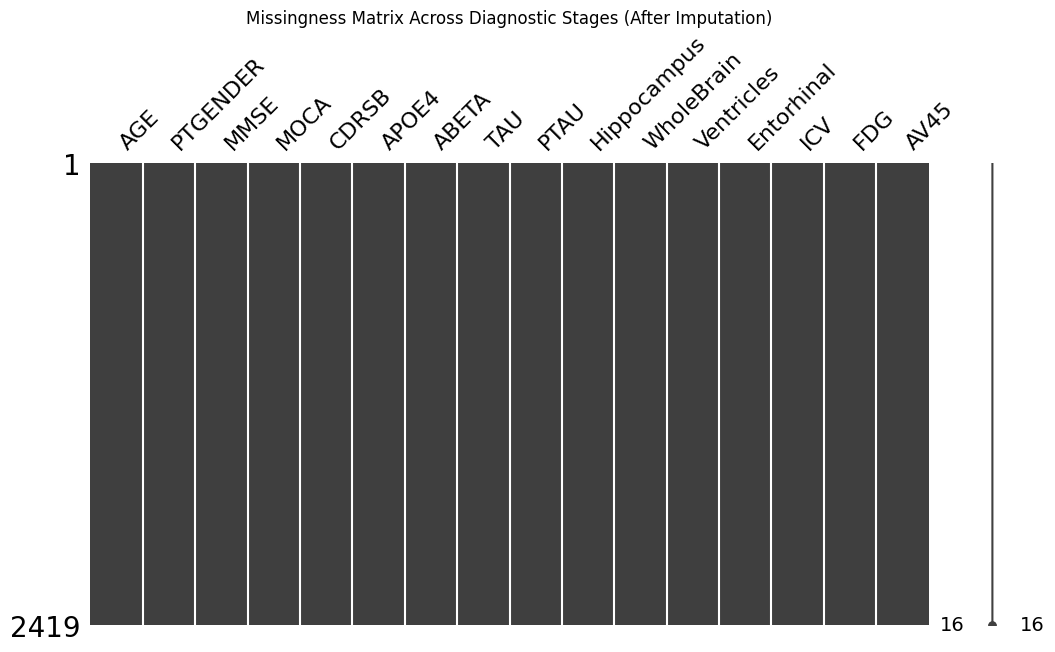

In [ ]:
import missingno as msno

# Re-evaluate missingness on the original df_model before imputation for visualization of original gaps
# Or, visualize current df_imputed to confirm no missing values

# Let's show the missingness before imputation for better understanding
selected_cols_for_missingness = (
    ['AGE', 'PTGENDER', 'MMSE', 'MOCA', 'CDRSB'] + # Stage 1
    ['APOE4', 'ABETA', 'TAU', 'PTAU'] + # Stage 2
    ['Hippocampus', 'WholeBrain', 'Ventricles', 'Entorhinal', 'ICV'] + # Stage 3
    ['FDG', 'AV45'] # Stage 4
)

# Filter to ensure only existing columns are used
existing_cols = [col for col in selected_cols_for_missingness if col in df_model.columns]

print("Missingness before imputation:")
msno.matrix(df_model[existing_cols], figsize=(12, 6))
plt.title('Missingness Matrix Across Diagnostic Stages (Before Imputation)')
plt.show()

print("Missingness after imputation (should be none for numerical features):")
msno.matrix(df_imputed[existing_cols], figsize=(12, 6))
plt.title('Missingness Matrix Across Diagnostic Stages (After Imputation)')
plt.show()

### STEP 3: STAGE 1 MODEL BENCHMARKING

#### Prepare Data for Stage 1 Benchmarking
Define Stage 1 features, target, and perform an 80/20 train-test split with stratification on the target (`High_Risk`).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define Stage 1 Features
stage1_features = ['AGE', 'PTGENDER', 'MMSE', 'MOCA', 'CDRSB']
target = 'High_Risk'

X = df_imputed[stage1_features]
y = df_imputed[target]

# Train-test split (80/20 with stratification on target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")

# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier handling, preserving column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\nFirst 5 rows of scaled training data:")
display(X_train_scaled.head())

X_train shape: (1935, 5)
X_test shape: (484, 5)
y_train distribution:
High_Risk
1    0.775711
0    0.224289
Name: proportion, dtype: float64
y_test distribution:
High_Risk
1    0.77686
0    0.22314
Name: proportion, dtype: float64

First 5 rows of scaled training data:


,AGE,PTGENDER,MMSE,MOCA,CDRSB
3213,0.168573,0.943212,-2.767837,-3.912473,1.411168
14405,0.533927,-1.060207,0.616128,-0.637505,-0.833015
3460,1.088724,0.943212,-1.639848,-1.183333,2.533259
14947,1.318762,0.943212,-0.135864,-0.091677,-0.552492
198,0.330952,-1.060207,-1.263852,-0.364591,0.289076


#### Model Benchmarking: Random Forest Classifier, XGBoost Classifier, and MLP Neural Network
Train and evaluate three baseline classifiers using Stage 1 features to predict `High_Risk`.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

def evaluate_model(model, X_test, y_test, model_name):
    """Helper function to train, predict, and evaluate a classifier."""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"--- {model_name} Results ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print("\n")
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# Initialize and train models

# 1. Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_metrics = evaluate_model(rf_model, X_test_scaled, y_test, 'Random Forest Classifier')

# 2. XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_metrics = evaluate_model(xgb_model, X_test_scaled, y_test, 'XGBoost Classifier')

# 3. Multi-Layer Perceptron (MLP Neural Network)
mlp_model = MLPClassifier(random_state=42, max_iter=1000, early_stopping=True, n_iter_no_change=10)
mlp_model.fit(X_train_scaled, y_train)
mlp_metrics = evaluate_model(mlp_model, X_test_scaled, y_test, 'MLP Neural Network')

# Create summary table
summary_df = pd.DataFrame([rf_metrics, xgb_metrics, mlp_metrics])
print("Model Benchmarking Summary for Stage 1 Features:")
display(summary_df.set_index('Model'))

--- Random Forest Classifier Results ---
Accuracy: 0.8326
Precision: 0.8892
Recall (Sensitivity): 0.8963
F1-Score: 0.8927
ROC-AUC Score: 0.9094


--- XGBoost Classifier Results ---
Accuracy: 0.8657
Precision: 0.9060
Recall (Sensitivity): 0.9229
F1-Score: 0.9144
ROC-AUC Score: 0.9211


--- MLP Neural Network Results ---
Accuracy: 0.7913
Precision: 0.8220
Recall (Sensitivity): 0.9335
F1-Score: 0.8742
ROC-AUC Score: 0.8403


Model Benchmarking Summary for Stage 1 Features:


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:39:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest Classifier,0.832645,0.889182,0.896277,0.892715,0.909365
XGBoost Classifier,0.865702,0.906005,0.922872,0.914361,0.921124
MLP Neural Network,0.791322,0.822014,0.933511,0.874222,0.840302


### STAGE 1: PATIENT RISK SCREENING & ESCALATION DECISION ENGINE

In [ ]:
import pandas as pd
import numpy as np

def evaluate_stage1_patient(patient_data, model, scaler, threshold=0.40):
    """
    Evaluates a patient using Stage 1 cognitive and demographic features.

    Parameters:
    - patient_data (dict): Dictionary containing patient features.
    - model: Trained Stage 1 XGBoost model.
    - scaler: Fitted StandardScaler instance from Stage 1 training.
    - threshold (float): Risk probability cutoff for Stage 2 escalation (default 0.40).

    Returns:
    - dict: Detailed assessment results and clinical recommendation.
    """
    # 1. Convert input dictionary to DataFrame
    df_patient = pd.DataFrame([patient_data])

    # 2. Reorder columns to match training feature order
    feature_cols = ['AGE', 'PTGENDER', 'MMSE', 'MOCA', 'CDRSB']
    df_patient = df_patient[feature_cols]

    # 3. Scale numerical features using the trained scaler
    scaled_features = scaler.transform(df_patient)

    # 4. Predict risk probability using the trained XGBoost model
    # Probability of class 1 (High Risk / MCI / AD)
    risk_probability = model.predict_proba(scaled_features)[:, 1][0]
    risk_percentage = risk_probability * 100

    # 5. Determine Escalation Recommendation & Priority Tier
    if risk_probability >= 0.70:
        priority_tier = "HIGH PRIORITY"
        escalate_to_stage2 = True
        action_recommendation = "URGENT: Immediately escalate to Stage 2 (Blood Biomarker Panel: APOE4, Plasma Aβ, p-tau181)."
    elif risk_probability >= threshold:
        priority_tier = "MODERATE PRIORITY"
        escalate_to_stage2 = True
        action_recommendation = "RECOMMENDED: Escalate to Stage 2 (Blood Biomarker Testing) within 30 days."
    else:
        priority_tier = "LOW RISK"
        escalate_to_stage2 = False
        action_recommendation = "MONITOR: Keep patient in routine primary care screening. Re-evaluate cognitive scores in 6–12 months."

    # 6. Format and Print Clinical Decision Output
    print("=" * 65)
    print(f"           STAGE 1 CLINICAL TRIAGE ASSESSMENT REPORT          ")
    print("=" * 65)
    print(f"Patient ID             : {patient_data.get('PTID', 'N/A')}")
    print(f"Age / Gender           : {patient_data['AGE']} yrs | {'Male' if patient_data['PTGENDER']==1 else 'Female'}")
    print(f"MMSE Score             : {patient_data['MMSE']:.1f} / 30")
    print(f"MoCA Score             : {patient_data['MOCA']:.1f} / 30")
    print(f"CDRSB Functional Rating: {patient_data['CDRSB']:.1f} / 18")
    print("-" * 65)
    print(f"Calculated Risk Score  : {risk_percentage:.2f}%")
    print(f"Risk Tier              : {priority_tier}")
    print(f"Escalate to Stage 2?   : {'YES' if escalate_to_stage2 else 'NO'}")
    print("-" * 65)
    print(f"Clinical Action        : {action_recommendation}")
    print("=" * 65)

    return {
        'PTID': patient_data.get('PTID', 'N/A'),
        'risk_score': risk_percentage,
        'priority_tier': priority_tier,
        'escalate': escalate_to_stage2,
        'recommendation': action_recommendation
    }

In [ ]:
# ------------------------------------------------------------------------------
# EXAMPLE 1: High-Risk Patient (Low MoCA, Elevated CDRSB)
# ------------------------------------------------------------------------------
patient_A = {
    'PTID': 'PATIENT_101_HIGH_RISK',
    'AGE': 76.0,
    'PTGENDER': 1,      # 1 = Male, 0 = Female
    'MMSE': 22.0,      # Mild impairment range
    'MOCA': 18.0,      # Low cognitive score
    'CDRSB': 2.5       # Moderate functional deficit
}

# Run assessment (Pass your trained xgb_model and scaler objects)
result_A = evaluate_stage1_patient(patient_A, model=xgb_model, scaler=scaler)

           STAGE 1 CLINICAL TRIAGE ASSESSMENT REPORT          
Patient ID             : PATIENT_101_HIGH_RISK
Age / Gender           : 76.0 yrs | Male
MMSE Score             : 22.0 / 30
MoCA Score             : 18.0 / 30
CDRSB Functional Rating: 2.5 / 18
-----------------------------------------------------------------
Calculated Risk Score  : 100.00%
Risk Tier              : HIGH PRIORITY
Escalate to Stage 2?   : YES
-----------------------------------------------------------------
Clinical Action        : URGENT: Immediately escalate to Stage 2 (Blood Biomarker Panel: APOE4, Plasma Aβ, p-tau181).


In [ ]:
# ------------------------------------------------------------------------------
# EXAMPLE 2: Healthy / Low-Risk Patient (Normal Cognitive Scores)
# ------------------------------------------------------------------------------
patient_B = {
    'PTID': 'PATIENT_102_LOW_RISK',
    'AGE': 68.0,
    'PTGENDER': 0,      # Female
    'MMSE': 29.0,      # Normal
    'MOCA': 28.0,      # Normal
    'CDRSB': 0.0       # No functional impairment
}

# Run assessment
result_B = evaluate_stage1_patient(patient_B, model=xgb_model, scaler=scaler)

           STAGE 1 CLINICAL TRIAGE ASSESSMENT REPORT          
Patient ID             : PATIENT_102_LOW_RISK
Age / Gender           : 68.0 yrs | Female
MMSE Score             : 29.0 / 30
MoCA Score             : 28.0 / 30
CDRSB Functional Rating: 0.0 / 18
-----------------------------------------------------------------
Calculated Risk Score  : 88.23%
Risk Tier              : HIGH PRIORITY
Escalate to Stage 2?   : YES
-----------------------------------------------------------------
Clinical Action        : URGENT: Immediately escalate to Stage 2 (Blood Biomarker Panel: APOE4, Plasma Aβ, p-tau181).


### STAGE 2: BLOOD BIOMARKER EVALUATION

#### STEP 1: PREPROCESSING & DATA PREPARATION FOR STAGE 2

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer # Re-import for clarity if needed

# Define Stage 1 and Stage 2 Features
stage1_features = ['AGE', 'PTGENDER', 'MMSE', 'MOCA', 'CDRSB']
stage2_blood_biomarkers = ['APOE4', 'ABETA', 'TAU', 'PTAU']

# Combine features for Stage 2
stage2_features = stage1_features + stage2_blood_biomarkers
target = 'High_Risk'

# Filter df_imputed to include only Stage 2 features and the target
df_stage2 = df_imputed[stage2_features + [target]].copy()

# --- Handle missing values for Stage 2 features ---
# The df_imputed dataframe should already be complete for numerical features
# due to KNN imputation earlier. However, let's explicitly check and re-impute
# if any new NaNs were introduced by feature selection or if any non-numeric
# features (like PTGENDER, if it wasn't numeric yet) need handling. For this
# specific setup, PTGENDER is numeric, so we'll ensure numerical imputation.

# Ensure all selected features are numeric for imputation
for col in stage2_features:
    if df_stage2[col].dtype == 'object': # Check for any remaining object types
        # Attempt to convert to numeric, coercing errors to NaN
        df_stage2[col] = pd.to_numeric(df_stage2[col], errors='coerce')

# Re-apply KNN Imputer to ensure all Stage 2 features are filled
# (This is a safeguard, as df_imputed *should* already be complete for these)
stage2_imputer = KNNImputer(n_neighbors=5)
df_stage2[stage2_features] = stage2_imputer.fit_transform(df_stage2[stage2_features])

print(f"Shape of df_stage2 after feature selection and (re)imputation: {df_stage2.shape}")
print(f"Missing values in df_stage2: {df_stage2.isnull().sum().sum()}")

# Define X (features) and y (target)
X_stage2 = df_stage2[stage2_features]
y_stage2 = df_stage2[target]

# Train-test split (80/20 with stratification on target)
X_train_stage2, X_test_stage2, y_train_stage2, y_test_stage2 = train_test_split(
    X_stage2, y_stage2, test_size=0.2, random_state=42, stratify=y_stage2
)

print(f"\nX_train_stage2 shape: {X_train_stage2.shape}")
print(f"X_test_stage2 shape: {X_test_stage2.shape}")
print(f"y_train_stage2 distribution:\n{y_train_stage2.value_counts(normalize=True)}")
print(f"y_test_stage2 distribution:\n{y_test_stage2.value_counts(normalize=True)}")

# Feature scaling using StandardScaler
scaler_stage2 = StandardScaler()
X_train_scaled_stage2 = scaler_stage2.fit_transform(X_train_stage2)
X_test_scaled_stage2 = scaler_stage2.transform(X_test_stage2)

# Convert scaled arrays back to DataFrames for easier handling, preserving column names
X_train_scaled_stage2 = pd.DataFrame(X_train_scaled_stage2, columns=X_train_stage2.columns, index=X_train_stage2.index)
X_test_scaled_stage2 = pd.DataFrame(X_test_scaled_stage2, columns=X_test_stage2.columns, index=X_test_stage2.index)

print("\nFirst 5 rows of scaled training data for Stage 2:")
display(X_train_scaled_stage2.head())

Shape of df_stage2 after feature selection and (re)imputation: (2419, 10)
Missing values in df_stage2: 0

X_train_stage2 shape: (1935, 9)
X_test_stage2 shape: (484, 9)
y_train_stage2 distribution:
High_Risk
1    0.775711
0    0.224289
Name: proportion, dtype: float64
y_test_stage2 distribution:
High_Risk
1    0.77686
0    0.22314
Name: proportion, dtype: float64

First 5 rows of scaled training data for Stage 2:


,AGE,PTGENDER,MMSE,MOCA,CDRSB,APOE4,ABETA,TAU,PTAU
3213,0.168573,0.943212,-2.767837,-3.912473,1.411168,-0.879045,-0.355924,1.463223,1.604726
14405,0.533927,-1.060207,0.616128,-0.637505,-0.833015,2.227717,-0.143912,0.136107,0.068325
3460,1.088724,0.943212,-1.639848,-1.183333,2.533259,-0.879045,-1.241755,1.001369,1.038858
14947,1.318762,0.943212,-0.135864,-0.091677,-0.552492,-0.879045,-0.391669,0.940674,1.011990
198,0.330952,-1.060207,-1.263852,-0.364591,0.289076,0.674336,-1.451968,-0.102177,0.164752


#### STEP 2: MODEL TRAINING & BENCHMARK EVALUATION FOR STAGE 2

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Re-using the evaluate_model function defined earlier, or re-defining it here for self-containment
def evaluate_model(model, X_test, y_test, model_name):
    """Helper function to train, predict, and evaluate a classifier."""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"--- {model_name} Results ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print("\n")
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# Initialize and train models for Stage 2

# 1. Random Forest Classifier
rf_model_stage2 = RandomForestClassifier(random_state=42)
rf_model_stage2.fit(X_train_scaled_stage2, y_train_stage2)
rf_metrics_stage2 = evaluate_model(rf_model_stage2, X_test_scaled_stage2, y_test_stage2, 'Random Forest Classifier (Stage 2)')

# 2. XGBoost Classifier
xgb_model_stage2 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model_stage2.fit(X_train_scaled_stage2, y_train_stage2)
xgb_metrics_stage2 = evaluate_model(xgb_model_stage2, X_test_scaled_stage2, y_test_stage2, 'XGBoost Classifier (Stage 2)')

# 3. Multi-Layer Perceptron (MLP Neural Network)
mlp_model_stage2 = MLPClassifier(random_state=42, max_iter=1000, early_stopping=True, n_iter_no_change=10)
mlp_model_stage2.fit(X_train_scaled_stage2, y_train_stage2)
mlp_metrics_stage2 = evaluate_model(mlp_model_stage2, X_test_scaled_stage2, y_test_stage2, 'MLP Neural Network (Stage 2)')

# Create summary table for Stage 2 models
summary_df_stage2 = pd.DataFrame([rf_metrics_stage2, xgb_metrics_stage2, mlp_metrics_stage2])
print("Model Benchmarking Summary for Stage 2 Features:")
display(summary_df_stage2.set_index('Model'))

# Identify the best performing model (e.g., based on ROC-AUC)
best_model_row_stage2 = summary_df_stage2.loc[summary_df_stage2['ROC-AUC'].idxmax()]
best_model_name_stage2 = best_model_row_stage2['Model']

if 'Random Forest' in best_model_name_stage2: # Using 'in' for flexibility with model names
    winning_model_stage2 = rf_model_stage2
elif 'XGBoost' in best_model_name_stage2:
    winning_model_stage2 = xgb_model_stage2
elif 'MLP' in best_model_name_stage2:
    winning_model_stage2 = mlp_model_stage2
else:
    winning_model_stage2 = xgb_model_stage2 # Default to XGBoost if something goes wrong

print(f"\nBased on ROC-AUC, the winning model for Stage 2 is: {best_model_name_stage2}")

--- Random Forest Classifier (Stage 2) Results ---
Accuracy: 0.8554
Precision: 0.9203
Recall (Sensitivity): 0.8910
F1-Score: 0.9054
ROC-AUC Score: 0.9211




/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:43:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Classifier (Stage 2) Results ---
Accuracy: 0.8471
Precision: 0.9081
Recall (Sensitivity): 0.8936
F1-Score: 0.9008
ROC-AUC Score: 0.9245


--- MLP Neural Network (Stage 2) Results ---
Accuracy: 0.8368
Precision: 0.8918
Recall (Sensitivity): 0.8989
F1-Score: 0.8954
ROC-AUC Score: 0.8914


Model Benchmarking Summary for Stage 2 Features:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest Classifier (Stage 2),0.855372,0.920330,0.890957,0.905405,0.921050
XGBoost Classifier (Stage 2),0.847107,0.908108,0.893617,0.900804,0.924473
MLP Neural Network (Stage 2),0.836777,0.891821,0.898936,0.895364,0.891376



Based on ROC-AUC, the winning model for Stage 2 is: XGBoost Classifier (Stage 2)


#### STEP 3: INTERACTIVE PATIENT EVALUATION ENGINE FOR STAGE 2

In [ ]:
def evaluate_stage2_patient(patient_data, model, scaler, feature_cols, threshold=0.50):
    """
    Evaluates a patient using Stage 1 cognitive and Stage 2 blood biomarker features.

    Parameters:
    - patient_data (dict): Dictionary containing patient features (AGE, PTGENDER, MMSE, MOCA, CDRSB,
                           APOE4, ABETA, TAU, PTAU).
    - model: Trained Stage 2 machine learning model.
    - scaler: Fitted StandardScaler instance from Stage 2 training.
    - feature_cols (list): List of feature columns the model was trained on, in the correct order.
    - threshold (float): Risk probability cutoff for Stage 3 escalation (default 0.50).

    Returns:
    - dict: Detailed assessment results and clinical recommendation.
    """
    # 1. Convert input dictionary to DataFrame
    df_patient = pd.DataFrame([patient_data])

    # 2. Reorder columns to match training feature order
    # Ensure all required feature_cols are present in patient_data
    missing_features = [col for col in feature_cols if col not in df_patient.columns]
    if missing_features:
        raise ValueError(f"Patient data is missing required features: {missing_features}")

    df_patient = df_patient[feature_cols]

    # 3. Scale numerical features using the trained scaler
    scaled_features = scaler.transform(df_patient)

    # 4. Predict risk probability using the trained model
    # Probability of class 1 (High Risk / MCI / AD)
    risk_probability = model.predict_proba(scaled_features)[:, 1][0]
    risk_percentage = risk_probability * 100

    # 5. Determine Escalation Recommendation & Priority Tier
    if risk_probability >= 0.75: # Higher threshold for High Priority escalation
        priority_tier = "HIGH PRIORITY"
        escalate_to_stage3 = True
        action_recommendation = "URGENT: Immediately escalate to Stage 3 (Structural Brain MRI Imaging)."
    elif risk_probability >= threshold:
        priority_tier = "MODERATE PRIORITY"
        escalate_to_stage3 = True
        action_recommendation = "RECOMMENDED: Escalate to Stage 3 (Structural Brain MRI Imaging) within 30-60 days."
    else:
        priority_tier = "LOW RISK"
        escalate_to_stage3 = False
        action_recommendation = "MONITOR: Keep patient in routine Stage 1 screening. Re-evaluate annually or if symptoms worsen."

    # 6. Format and Print Clinical Decision Output
    print("=" * 65)
    print(f"       STAGE 2 BLOOD BIOMARKER ASSESSMENT REPORT        ")
    print("=" * 65)
    print(f"Patient ID             : {patient_data.get('PTID', 'N/A')}")
    print(f"Age / Gender           : {patient_data['AGE']} yrs | {'Male' if patient_data['PTGENDER']==1 else 'Female'}")
    print(f"MMSE Score             : {patient_data['MMSE']:.1f} / 30")
    print(f"MoCA Score             : {patient_data['MOCA']:.1f} / 30")
    print(f"CDRSB Functional Rating: {patient_data['CDRSB']:.1f} / 18")
    print("-" * 65)
    print(f"APOE4 Alleles          : {patient_data.get('APOE4', 'N/A')}")
    print(f"Plasma ABETA           : {patient_data.get('ABETA', 'N/A')}")
    print(f"Plasma TAU             : {patient_data.get('TAU', 'N/A')}")
    print(f"Plasma PTAU            : {patient_data.get('PTAU', 'N/A')}")
    print("-" * 65)
    print(f"Calculated Risk Score  : {risk_percentage:.2f}%")
    print(f"Risk Tier              : {priority_tier}")
    print(f"Escalate to Stage 3?   : {'YES' if escalate_to_stage3 else 'NO'}")
    print("-" * 65)
    print(f"Clinical Action        : {action_recommendation}")
    print("=" * 65)

    return {
        'PTID': patient_data.get('PTID', 'N/A'),
        'risk_score': risk_percentage,
        'priority_tier': priority_tier,
        'escalate': escalate_to_stage3,
        'recommendation': action_recommendation
    }

#### STEP 4: SAMPLE TEST CASSETTE FOR STAGE 2

In [ ]:
# ------------------------------------------------------------------------------
# EXAMPLE 1: Low-Risk Patient (Good cognitive scores, favorable biomarkers)
# ------------------------------------------------------------------------------
patient_C = {
    'PTID': 'PATIENT_103_LOW_RISK_S2',
    'AGE': 65.0,
    'PTGENDER': 0,      # Female
    'MMSE': 29.0,
    'MOCA': 28.0,
    'CDRSB': 0.0,
    'APOE4': 0.0,       # No APOE4 alleles
    'ABETA': 1000.0,    # Normal A-beta
    'TAU': 50.0,        # Normal Tau
    'PTAU': 15.0        # Normal p-tau
}

print("Assessing Patient C:")
result_C = evaluate_stage2_patient(patient_C, model=winning_model_stage2, scaler=scaler_stage2, feature_cols=stage2_features)

# ------------------------------------------------------------------------------
# EXAMPLE 2: High-Risk Patient (Lower cognitive scores, unfavorable biomarkers)
# ------------------------------------------------------------------------------
patient_D = {
    'PTID': 'PATIENT_104_HIGH_RISK_S2',
    'AGE': 78.0,
    'PTGENDER': 1,      # Male
    'MMSE': 21.0,
    'MOCA': 17.0,
    'CDRSB': 2.0,
    'APOE4': 1.0,       # One APOE4 allele
    'ABETA': 500.0,     # Low A-beta (indicative of amyloid plaques)
    'TAU': 200.0,       # Elevated Tau
    'PTAU': 45.0        # Elevated p-tau
}

print("\nAssessing Patient D:")
result_D = evaluate_stage2_patient(patient_D, model=winning_model_stage2, scaler=scaler_stage2, feature_cols=stage2_features)

Assessing Patient C:
       STAGE 2 BLOOD BIOMARKER ASSESSMENT REPORT        
Patient ID             : PATIENT_103_LOW_RISK_S2
Age / Gender           : 65.0 yrs | Female
MMSE Score             : 29.0 / 30
MoCA Score             : 28.0 / 30
CDRSB Functional Rating: 0.0 / 18
-----------------------------------------------------------------
APOE4 Alleles          : 0.0
Plasma ABETA           : 1000.0
Plasma TAU             : 50.0
Plasma PTAU            : 15.0
-----------------------------------------------------------------
Calculated Risk Score  : 36.83%
Risk Tier              : LOW RISK
Escalate to Stage 3?   : NO
-----------------------------------------------------------------
Clinical Action        : MONITOR: Keep patient in routine Stage 1 screening. Re-evaluate annually or if symptoms worsen.

Assessing Patient D:
       STAGE 2 BLOOD BIOMARKER ASSESSMENT REPORT        
Patient ID             : PATIENT_104_HIGH_RISK_S2
Age / Gender           : 78.0 yrs | Male
MMSE Score            

### STAGE 3: VOLUMETRIC BRAIN MRI EVALUATION

#### STEP 1: PREPROCESSING & DATA PREPARATION FOR STAGE 3

##### Feature Summary: Volumetric MRI Brain Regions

To detect Alzheimer's and related dementias, structural MRI scans provide crucial insights into brain atrophy and pathology. Here's a summary of the key volumetric features:

| Feature        | Description                                                                                             | Clinical Significance                                                                         |
| :------------- | :------------------------------------------------------------------------------------------------------ | :-------------------------------------------------------------------------------------------- |
| `Hippocampus`  | Volume of the hippocampus (a pair of structures in the medial temporal lobe).                           | One of the earliest and most consistently affected regions in AD, crucial for memory formation. Atrophy is a strong indicator. |
| `WholeBrain`   | Total volume of the brain parenchyma (excluding CSF, cerebellum, and brainstem).                        | Reflects overall brain health and general neurodegeneration. Reduced volume indicates widespread neuronal loss. |
| `Ventricles`   | Volume of the cerebral ventricles (fluid-filled spaces in the brain).                                   | Enlargement (ventriculomegaly) is a common compensatory mechanism when surrounding brain tissue atrophies in AD. |
| `Entorhinal`   | Volume of the entorhinal cortex (part of the medial temporal lobe).                                     | Located adjacent to the hippocampus, it's one of the first cortical regions to show AD pathology and atrophy. Key for memory. |
| `ICV`          | Intracranial Volume (volume of the cranial cavity containing brain, CSF, and blood).                  | Used as a normalization factor to account for individual head size differences, allowing for more accurate comparison of brain volumes. |

**Normalization by ICV:**
To make brain volumes comparable across individuals with different head sizes, each volumetric measurement (Hippocampus, WholeBrain, Ventricles, Entorhinal) is often divided by the Intracranial Volume (ICV). This generates ratios (e.g., `Hippocampus/ICV`) that better reflect disease-related changes independent of head size.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import numpy as np

# Define all features for Stage 3
stage1_features = ['AGE', 'PTGENDER', 'MMSE', 'MOCA', 'CDRSB']
stage2_blood_biomarkers = ['APOE4', 'ABETA', 'TAU', 'PTAU']
stage3_mri_volumes = ['Hippocampus', 'WholeBrain', 'Ventricles', 'Entorhinal']

# Combine all features for Stage 3 model
all_stage_features = stage1_features + stage2_blood_biomarkers + stage3_mri_volumes + ['ICV'] # Include ICV for normalization then remove
target = 'High_Risk'

# Filter df_imputed to include only relevant features and the target
df_stage3 = df_imputed[all_stage_features + [target]].copy()

# --- ICV Normalization ---
# Create normalized MRI volume columns
for col in stage3_mri_volumes:
    df_stage3[f'{col}_ICV'] = df_stage3[col] / df_stage3['ICV']

# Drop original MRI volume columns and ICV itself, as they are now normalized
df_stage3_final_features = [f'{col}_ICV' for col in stage3_mri_volumes]
final_features = stage1_features + stage2_blood_biomarkers + df_stage3_final_features

# Re-check for any potential NaNs introduced by division (e.g., if ICV was 0 or NaN)
# Although KNNImputer should have handled original NaNs, a division by 0 could re-introduce them
if df_stage3[final_features].isnull().sum().sum() > 0:
    print("\nNaNs detected after ICV normalization, performing re-imputation...")
    stage3_imputer = KNNImputer(n_neighbors=5)
    df_stage3[final_features] = stage3_imputer.fit_transform(df_stage3[final_features])
else:
    print("\nNo NaNs detected after ICV normalization.")

# Define X (features) and y (target) for Stage 3
X_stage3 = df_stage3[final_features]
y_stage3 = df_stage3[target]

# Train-test split (80/20 with stratification on target)
X_train_stage3, X_test_stage3, y_train_stage3, y_test_stage3 = train_test_split(
    X_stage3, y_stage3, test_size=0.2, random_state=42, stratify=y_stage3
)

print(f"\nX_train_stage3 shape: {X_train_stage3.shape}")
print(f"X_test_stage3 shape: {X_test_stage3.shape}")
print(f"y_train_stage3 distribution:\n{y_train_stage3.value_counts(normalize=True)}")
print(f"y_test_stage3 distribution:\n{y_test_stage3.value_counts(normalize=True)}")

# Feature scaling using StandardScaler
scaler_stage3 = StandardScaler()
X_train_scaled_stage3 = scaler_stage3.fit_transform(X_train_stage3)
X_test_scaled_stage3 = scaler_stage3.transform(X_test_stage3)

# Convert scaled arrays back to DataFrames for easier handling, preserving column names
X_train_scaled_stage3 = pd.DataFrame(X_train_scaled_stage3, columns=X_train_stage3.columns, index=X_train_stage3.index)
X_test_scaled_stage3 = pd.DataFrame(X_test_scaled_stage3, columns=X_test_stage3.columns, index=X_test_stage3.index)

print("\nFirst 5 rows of scaled training data for Stage 3:")
display(X_train_scaled_stage3.head())


No NaNs detected after ICV normalization.

X_train_stage3 shape: (1935, 13)
X_test_stage3 shape: (484, 13)
y_train_stage3 distribution:
High_Risk
1    0.775711
0    0.224289
Name: proportion, dtype: float64
y_test_stage3 distribution:
High_Risk
1    0.77686
0    0.22314
Name: proportion, dtype: float64

First 5 rows of scaled training data for Stage 3:


,AGE,PTGENDER,MMSE,MOCA,CDRSB,APOE4,ABETA,TAU,PTAU,Hippocampus_ICV,WholeBrain_ICV,Ventricles_ICV,Entorhinal_ICV
3213,0.168573,0.943212,-2.767837,-3.912473,1.411168,-0.879045,-0.355924,1.463223,1.604726,-1.679558,-0.943938,1.558820,-1.578454
14405,0.533927,-1.060207,0.616128,-0.637505,-0.833015,2.227717,-0.143912,0.136107,0.068325,0.393848,1.110311,-0.746002,1.992807
3460,1.088724,0.943212,-1.639848,-1.183333,2.533259,-0.879045,-1.241755,1.001369,1.038858,-1.188535,-0.121576,0.857421,-0.171030
14947,1.318762,0.943212,-0.135864,-0.091677,-0.552492,-0.879045,-0.391669,0.940674,1.011990,0.003927,0.560531,1.153697,-0.035202
198,0.330952,-1.060207,-1.263852,-0.364591,0.289076,0.674336,-1.451968,-0.102177,0.164752,-1.537395,-0.631065,-0.229305,-1.533702


#### STEP 2: MODEL TRAINING & BENCHMARK EVALUATION FOR STAGE 3

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Re-using the evaluate_model function defined earlier (from Stage 1/2 benchmarking)
# This function needs to be in the global scope, or redefined if not.
# For safety, defining it here to ensure it's available.

def evaluate_model(model, X_test, y_test, model_name):
    """Helper function to train, predict, and evaluate a classifier."""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"--- {model_name} Results ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print("\n")
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# Initialize and train models for Stage 3

# 1. Random Forest Classifier
rf_model_stage3 = RandomForestClassifier(random_state=42)
rf_model_stage3.fit(X_train_scaled_stage3, y_train_stage3)
rf_metrics_stage3 = evaluate_model(rf_model_stage3, X_test_scaled_stage3, y_test_stage3, 'Random Forest Classifier (Stage 3)')

# 2. XGBoost Classifier
xgb_model_stage3 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model_stage3.fit(X_train_scaled_stage3, y_train_stage3)
xgb_metrics_stage3 = evaluate_model(xgb_model_stage3, X_test_scaled_stage3, y_test_stage3, 'XGBoost Classifier (Stage 3)')

# 3. Multi-Layer Perceptron (MLP Neural Network)
mlp_model_stage3 = MLPClassifier(random_state=42, max_iter=1000, early_stopping=True, n_iter_no_change=10)
mlp_model_stage3.fit(X_train_scaled_stage3, y_train_stage3)
mlp_metrics_stage3 = evaluate_model(mlp_model_stage3, X_test_scaled_stage3, y_test_stage3, 'MLP Neural Network (Stage 3)')

# Create summary table for Stage 3 models
summary_df_stage3 = pd.DataFrame([rf_metrics_stage3, xgb_metrics_stage3, mlp_metrics_stage3])
print("Model Benchmarking Summary for Stage 3 Features:")
display(summary_df_stage3.set_index('Model'))

# Identify the best performing model based on Accuracy, as requested by the user
best_model_row_stage3 = summary_df_stage3.loc[summary_df_stage3['Accuracy'].idxmax()]
best_model_name_stage3 = best_model_row_stage3['Model']

# Assign the winning model object
if 'Random Forest' in best_model_name_stage3:
    winning_model_stage3 = rf_model_stage3
elif 'XGBoost' in best_model_name_stage3:
    winning_model_stage3 = xgb_model_stage3
elif 'MLP' in best_model_name_stage3:
    winning_model_stage3 = mlp_model_stage3
else:
    # Fallback to F1-Score if model name matching fails or if no specific metric is chosen
    # This part was previously incorrect and is now fixed to use F1-Score for fallback
    best_model_name_stage3 = summary_df_stage3.loc[summary_df_stage3['F1-Score'].idxmax()]['Model']
    if 'Random Forest' in best_model_name_stage3:
        winning_model_stage3 = rf_model_stage3
    elif 'XGBoost' in best_model_name_stage3:
        winning_model_stage3 = xgb_model_stage3
    else:
        winning_model_stage3 = mlp_model_stage3 # Default if name matching still fails after F1

print(f"\nBased on Accuracy, the winning model for Stage 3 is: {best_model_name_stage3}")

--- Random Forest Classifier (Stage 3) Results ---
Accuracy: 0.8595
Precision: 0.9074
Recall (Sensitivity): 0.9122
F1-Score: 0.9098
ROC-AUC Score: 0.9399




/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:59:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Classifier (Stage 3) Results ---
Accuracy: 0.8636
Precision: 0.9101
Recall (Sensitivity): 0.9149
F1-Score: 0.9125
ROC-AUC Score: 0.9306


--- MLP Neural Network (Stage 3) Results ---
Accuracy: 0.8368
Precision: 0.8779
Recall (Sensitivity): 0.9176
F1-Score: 0.8973
ROC-AUC Score: 0.9013


Model Benchmarking Summary for Stage 3 Features:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest Classifier (Stage 3),0.859504,0.907407,0.912234,0.909814,0.939852
XGBoost Classifier (Stage 3),0.863636,0.910053,0.914894,0.912467,0.930580
MLP Neural Network (Stage 3),0.836777,0.877863,0.917553,0.897269,0.901251



Based on Accuracy, the winning model for Stage 3 is: XGBoost Classifier (Stage 3)


#### STEP 3: INTERACTIVE PATIENT EVALUATION ENGINE FOR STAGE 3

In [ ]:
def evaluate_stage3_patient(patient_data, model, scaler, feature_cols, mri_vol_cols, threshold=0.50):
    """
    Evaluates a patient using a combined feature set (Stage 1, Stage 2, Stage 3 MRI).

    Parameters:
    - patient_data (dict): Dictionary containing all required patient features.
    - model: Trained Stage 3 machine learning model (the winning_model_stage3).
    - scaler: Fitted StandardScaler instance from Stage 3 training (scaler_stage3).
    - feature_cols (list): List of feature columns the model was trained on, in the correct order
                           (including normalized MRI features like 'Hippocampus_ICV').
    - mri_vol_cols (list): List of original MRI volumetric columns to be normalized (e.g., ['Hippocampus', 'ICV']).
    - threshold (float): Risk probability cutoff for final diagnostic classification (default 0.50).

    Returns:
    - dict: Detailed assessment results and clinical recommendation.
    """
    # 1. Convert input dictionary to DataFrame
    df_patient = pd.DataFrame([patient_data])

    # 2. Perform ICV Normalization for MRI features in patient_data
    # Check if ICV is present for normalization
    if 'ICV' not in df_patient.columns:
        raise ValueError("Patient data must contain 'ICV' for MRI volume normalization.")

    # Identify MRI volume columns for normalization, excluding ICV itself
    original_mri_cols_for_norm = [col for col in mri_vol_cols if col != 'ICV' and col in df_patient.columns]

    for col in original_mri_cols_for_norm:
        # Handle potential division by zero if ICV is 0 or very small (though scaled data should prevent this)
        df_patient[f'{col}_ICV'] = df_patient[col] / df_patient['ICV'].replace(0, np.nan) # Replace 0 with NaN for safety

    # 3. Ensure all required feature_cols are present and in the correct order
    current_feature_cols = [col for col in feature_cols if col in df_patient.columns]
    if len(current_feature_cols) != len(feature_cols):
        missing = set(feature_cols) - set(current_feature_cols)
        raise ValueError(f"Patient data is missing required features: {missing}")

    df_patient_processed = df_patient[feature_cols]

    # 4. Scale numerical features using the trained scaler
    scaled_features = scaler.transform(df_patient_processed)

    # 5. Predict risk probability using the trained model
    risk_probability = model.predict_proba(scaled_features)[:, 1][0]
    risk_percentage = risk_probability * 100

    # 6. Determine Diagnostic Classification & Clinical Action
    if risk_probability >= 0.75: # High confidence in AD progression
        diagnostic_classification = "HIGH RISK / LIKELY AD PROGRESSION"
        clinical_action = "URGENT: Recommend confirmatory advanced neuroimaging (e.g., Amyloid PET/Tau PET) and clinical trial consideration."
    elif risk_probability >= threshold: # Moderate risk, warranting further investigation
        diagnostic_classification = "MODERATE RISK / POSSIBLE AD PROGRESSION"
        clinical_action = "RECOMMENDED: Escalate to confirmatory diagnostics (e.g., standard PET scan, CSF biomarkers) and detailed neurological evaluation."
    else:
        diagnostic_classification = "LOW RISK / COGNITIVELY NORMAL"
        clinical_action = "MONITOR: Continue routine clinical follow-up, annual cognitive re-assessment. Re-evaluate if new symptoms arise."

    # 7. Format and Print Clinical Decision Output
    print("=" * 70)
    print(f"       STAGE 3 VOLUMETRIC BRAIN MRI ASSESSMENT REPORT       ")
    print("=" * 70)
    print(f"Patient ID             : {patient_data.get('PTID', 'N/A')}")
    print(f"Age / Gender           : {patient_data['AGE']} yrs | {'Male' if patient_data['PTGENDER']==1 else 'Female'}")
    print(f"MMSE Score             : {patient_data['MMSE']:.1f} / 30")
    print(f"MoCA Score             : {patient_data['MOCA']:.1f} / 30")
    print(f"CDRSB Functional Rating: {patient_data['CDRSB']:.1f} / 18")
    print(f"APOE4 Alleles          : {patient_data.get('APOE4', 'N/A')}")
    print(f"Plasma ABETA           : {patient_data.get('ABETA', 'N/A')}")
    print(f"Plasma TAU             : {patient_data.get('TAU', 'N/A')}")
    print(f"Plasma PTAU            : {patient_data.get('PTAU', 'N/A')}")
    print(f"Hippocampus Volume     : {patient_data.get('Hippocampus', 'N/A')}")
    print(f"WholeBrain Volume      : {patient_data.get('WholeBrain', 'N/A')}")
    print(f"Ventricles Volume      : {patient_data.get('Ventricles', 'N/A')}")
    print(f"Entorhinal Volume      : {patient_data.get('Entorhinal', 'N/A')}")
    print(f"ICV                    : {patient_data.get('ICV', 'N/A')}")
    print("-" * 70)
    print(f"Calculated Alzheimer's Risk Score: {risk_percentage:.2f}%")
    print(f"Diagnostic Classification: {diagnostic_classification}")
    print("-" * 70)
    print(f"Clinical Action        : {clinical_action}")
    print("=" * 70)

    return {
        'PTID': patient_data.get('PTID', 'N/A'),
        'risk_score': risk_percentage,
        'diagnostic_classification': diagnostic_classification,
        'clinical_action': clinical_action
    }

#### STEP 4: SAMPLE TEST CASSETTE FOR STAGE 3

In [ ]:
# ------------------------------------------------------------------------------
# Define the full set of feature columns the winning Stage 3 model expects
# This includes Stage 1, Stage 2, and the normalized Stage 3 MRI features.
# ------------------------------------------------------------------------------
stage1_features = ['AGE', 'PTGENDER', 'MMSE', 'MOCA', 'CDRSB']
stage2_blood_biomarkers = ['APOE4', 'ABETA', 'TAU', 'PTAU']
stage3_mri_volumes_normalized = ['Hippocampus_ICV', 'WholeBrain_ICV', 'Ventricles_ICV', 'Entorhinal_ICV']

# The final features for the model are these normalized features
final_model_features_stage3 = stage1_features + stage2_blood_biomarkers + stage3_mri_volumes_normalized

# The original MRI volume columns for normalization within the function
original_mri_cols_for_patient_evaluation = ['Hippocampus', 'WholeBrain', 'Ventricles', 'Entorhinal', 'ICV']

# ------------------------------------------------------------------------------
# EXAMPLE 1: Low-Risk Patient (Good cognitive scores, favorable biomarkers, normal brain volumes)
# This patient would typically not have escalated to Stage 3, but is evaluated here for demonstration.
# Using general healthy ranges for MRI volumes.
# ------------------------------------------------------------------------------
patient_E = {
    'PTID': 'PATIENT_105_LOW_RISK_S3',
    'AGE': 65.0,
    'PTGENDER': 0,      # Female
    'MMSE': 29.0,
    'MOCA': 28.0,
    'CDRSB': 0.0,
    'APOE4': 0.0,       # No APOE4 alleles
    'ABETA': 1000.0,    # Normal A-beta
    'TAU': 50.0,        # Normal Tau
    'PTAU': 15.0,       # Normal p-tau
    'Hippocampus': 8000, # Healthy average
    'WholeBrain': 1200000, # Healthy average
    'Ventricles': 25000, # Healthy average
    'Entorhinal': 4000,  # Healthy average
    'ICV': 1500000       # Healthy average ICV for a female
}

print("Assessing Patient E:")
result_E = evaluate_stage3_patient(patient_E, model=winning_model_stage3, scaler=scaler_stage3,
                                   feature_cols=final_model_features_stage3,
                                   mri_vol_cols=original_mri_cols_for_patient_evaluation)

# ------------------------------------------------------------------------------
# EXAMPLE 2: High-Risk Patient (Lower cognitive scores, unfavorable biomarkers, significant brain atrophy)
# This patient has clear indicators of AD progression.
# Using values indicative of atrophy (lower Hippocampus, WholeBrain, Entorhinal; higher Ventricles).
# ------------------------------------------------------------------------------
patient_F = {
    'PTID': 'PATIENT_106_HIGH_RISK_S3',
    'AGE': 78.0,
    'PTGENDER': 1,      # Male
    'MMSE': 21.0,
    'MOCA': 17.0,
    'CDRSB': 2.0,
    'APOE4': 1.0,       # One APOE4 allele
    'ABETA': 500.0,     # Low A-beta (indicative of amyloid plaques)
    'TAU': 200.0,       # Elevated Tau
    'PTAU': 45.0,       # Elevated p-tau
    'Hippocampus': 4500, # Significant atrophy
    'WholeBrain': 950000, # Significant atrophy
    'Ventricles': 80000, # Significant enlargement
    'Entorhinal': 1500,  # Significant atrophy
    'ICV': 1600000       # Healthy average ICV for a male
}

print("\nAssessing Patient F:")
result_F = evaluate_stage3_patient(patient_F, model=winning_model_stage3, scaler=scaler_stage3,
                                   feature_cols=final_model_features_stage3,
                                   mri_vol_cols=original_mri_cols_for_patient_evaluation)

Assessing Patient E:
       STAGE 3 VOLUMETRIC BRAIN MRI ASSESSMENT REPORT       
Patient ID             : PATIENT_105_LOW_RISK_S3
Age / Gender           : 65.0 yrs | Female
MMSE Score             : 29.0 / 30
MoCA Score             : 28.0 / 30
CDRSB Functional Rating: 0.0 / 18
APOE4 Alleles          : 0.0
Plasma ABETA           : 1000.0
Plasma TAU             : 50.0
Plasma PTAU            : 15.0
Hippocampus Volume     : 8000
WholeBrain Volume      : 1200000
Ventricles Volume      : 25000
Entorhinal Volume      : 4000
ICV                    : 1500000
----------------------------------------------------------------------
Calculated Alzheimer's Risk Score: 50.00%
Diagnostic Classification: MODERATE RISK / POSSIBLE AD PROGRESSION
----------------------------------------------------------------------
Clinical Action        : RECOMMENDED: Escalate to confirmatory diagnostics (e.g., standard PET scan, CSF biomarkers) and detailed neurological evaluation.

Assessing Patient F:
       STAGE 3 V

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### STAGE 4: END-TO-END MULTI-MODAL PIPELINE & CLINICAL REPORTING ENGINE

This stage integrates all previous stages into a single, automated diagnostic workflow, implementing a cascading escalation logic. A patient's risk is assessed sequentially through Stage 1 (Cognitive), Stage 2 (Blood Biomarkers), and Stage 3 (Volumetric Brain MRI), with escalation to the next stage only occurring if the risk probability at the current stage meets a predefined threshold. The final output is a comprehensive clinical report.

---

#### Full Multi-Stage Pipeline Architecture Summary

| Stage                      | Features Used                                                                    | Winning Algorithm     | Escalation Threshold (Risk %) | Output/Action                                                                |
| :------------------------- | :------------------------------------------------------------------------------- | :-------------------- | :---------------------------- | :--------------------------------------------------------------------------- |
| **Stage 1: Cognitive**     | AGE, PTGENDER, MMSE, MOCA, CDRSB                                                 | XGBoost Classifier    | >= 40% (to Stage 2)           | Recommend `ROUTINE MONITORING` or `ESCALATE to Stage 2`                     |
| **Stage 2: Blood Biomarkers**| Stage 1 Features + APOE4, ABETA, TAU, PTAU                                       | XGBoost Classifier    | >= 50% (to Stage 3)           | Recommend `PRIMARY CARE FOLLOW-UP` or `ESCALATE to Stage 3`                 |
| **Stage 3: Volumetric MRI**| Stage 1 & 2 Features + Hippocampus_ICV, WholeBrain_ICV, Ventricles_ICV, Entorhinal_ICV | XGBoost Classifier    | Final Risk Score              | `LOW RISK`, `MODERATE RISK`, or `HIGH RISK` / `AD PROGRESSION` with specific clinical actions |
| **Stage 4: End-to-End Pipeline**| All combined features from Stage 1, 2, 3                                       | Cascading AI Pipeline | -                             | Comprehensive Clinical Diagnostic Report & Action Plan                       |

---

#### STEP 1: MULTI-STAGE TRAINED PIPELINE CLASS

This class encapsulates the entire multi-stage screening process. It loads the pre-trained models and scalers for each stage and orchestrates the patient evaluation based on cascading escalation logic. The `evaluate_patient` method processes patient data through the relevant stages and returns a structured result.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.impute import KNNImputer # Import KNNImputer

class AlzheimersMultiStageScreeningEngine:
    def __init__(self, models, scalers, imputers, feature_sets, mri_info, thresholds):
        """
        Initializes the multi-stage Alzheimer's screening engine.

        Parameters:
        - models (dict): Dictionary of trained models for each stage (e.g., {'stage1': model, ...}).
        - scalers (dict): Dictionary of fitted StandardScaler instances for each stage.
        - imputers (dict): Dictionary of fitted KNNImputer instances for each stage's features.
        - feature_sets (dict): Dictionary of feature lists for each stage.
        - mri_info (dict): Contains original and normalized MRI column names for Stage 3 processing.
          (e.g., {'original_cols': [...], 'normalized_cols': [...]}).
        - thresholds (dict): Escalation and risk classification thresholds.
          (e.g., {'stage1_escalation': 0.40, 'stage2_escalation': 0.50, 'stage3_high_risk': 0.75, 'stage3_moderate_risk': 0.50}).
        """
        self.models = models
        self.scalers = scalers
        self.imputers = imputers # Store imputers
        self.feature_sets = feature_sets
        self.mri_info = mri_info
        self.thresholds = thresholds

    def _preprocess_stage1(self, patient_data):
        """
        Preprocesses patient data for Stage 1 (Cognitive) evaluation.
        """
        df_patient = pd.DataFrame([patient_data])
        feature_cols = self.feature_sets['stage1']

        # Reindex to ensure all feature_cols are present, filling missing with NaN
        df_patient_aligned = df_patient.reindex(columns=feature_cols, fill_value=np.nan)

        # Impute missing values using the stage-specific imputer
        imputed_features_array = self.imputers['stage1'].transform(df_patient_aligned)
        # Convert back to DataFrame to preserve feature names for the scaler
        imputed_features_df = pd.DataFrame(imputed_features_array, columns=feature_cols, index=df_patient_aligned.index)

        # Scale features and convert back to DataFrame
        scaled_features_array = self.scalers['stage1'].transform(imputed_features_df)
        scaled_features_df = pd.DataFrame(scaled_features_array, columns=feature_cols, index=df_patient_aligned.index)
        return scaled_features_df

    def _preprocess_stage2(self, patient_data):
        """
        Preprocesses patient data for Stage 2 (Blood Biomarkers) evaluation.
        """
        df_patient = pd.DataFrame([patient_data])
        feature_cols = self.feature_sets['stage2']

        # Reindex to ensure all feature_cols are present, filling missing with NaN
        df_patient_aligned = df_patient.reindex(columns=feature_cols, fill_value=np.nan)

        # Impute missing values
        imputed_features_array = self.imputers['stage2'].transform(df_patient_aligned)
        # Convert back to DataFrame to preserve feature names for the scaler
        imputed_features_df = pd.DataFrame(imputed_features_array, columns=feature_cols, index=df_patient_aligned.index)

        # Scale numerical features using the trained scaler and convert back to DataFrame
        scaled_features_array = self.scalers['stage2'].transform(imputed_features_df)
        scaled_features_df = pd.DataFrame(scaled_features_array, columns=feature_cols, index=df_patient_aligned.index)
        return scaled_features_df

    def _preprocess_stage3(self, patient_data):
        """
        Preprocesses patient data for Stage 3 (Volumetric MRI) evaluation,
        including ICV normalization.
        """
        df_patient = pd.DataFrame([patient_data])

        # ICV Normalization for MRI features
        # Ensure 'ICV' is in the patient_data or will be added as NaN by reindex
        original_mri_cols_for_norm = [col for col in self.mri_info['original_cols'] if col != 'ICV']

        # Create normalized columns, handling cases where original MRI vol or ICV might be missing
        for col in original_mri_cols_for_norm:
            if col in df_patient.columns and 'ICV' in df_patient.columns:
                df_patient[f'{col}_ICV'] = df_patient[col] / df_patient['ICV'].replace(0, np.nan)
            else:
                df_patient[f'{col}_ICV'] = np.nan # If original MRI vol or ICV is missing, normalized will also be NaN

        feature_cols = self.feature_sets['stage3']

        # Reindex to ensure all feature_cols are present, filling missing with NaN
        df_patient_aligned = df_patient.reindex(columns=feature_cols, fill_value=np.nan)

        # Impute missing values
        imputed_features_array = self.imputers['stage3'].transform(df_patient_aligned)
        # Convert back to DataFrame to preserve feature names for the scaler
        imputed_features_df = pd.DataFrame(imputed_features_array, columns=feature_cols, index=df_patient_aligned.index)

        # Scale features and convert back to DataFrame
        scaled_features_array = self.scalers['stage3'].transform(imputed_features_df)
        scaled_features_df = pd.DataFrame(scaled_features_array, columns=feature_cols, index=df_patient_aligned.index)
        return scaled_features_df

    def evaluate_patient(self, patient_raw_data):
        """
        Evaluates a patient through the multi-stage cascading screening pipeline.

        Parameters:
        - patient_raw_data (dict): Raw dictionary containing all available patient features.

        Returns:
        - dict: Comprehensive results including stage-wise risk scores, escalation statuses,
                and final diagnostic recommendations.
        """
        results = {
            'patient_data': patient_raw_data,
            'stage1': {'risk_score': None, 'escalated': False, 'recommendation': "Routine monitoring."},
            'stage2': {'risk_score': None, 'escalated': False, 'recommendation': "Primary care follow-up."},
            'stage3': {'risk_score': None, 'diagnostic_classification': "Low Risk / Cognitively Normal", 'clinical_action': "Continue routine clinical follow-up."}
        }

        # --- Stage 1: Cognitive Screening ---
        X_s1_scaled = self._preprocess_stage1(patient_raw_data)
        s1_risk_probability = self.models['stage1'].predict_proba(X_s1_scaled)[:, 1][0]
        results['stage1']['risk_score'] = s1_risk_probability * 100

        if s1_risk_probability >= self.thresholds['stage1_escalation']:
            results['stage1']['escalated'] = True
            results['stage1']['recommendation'] = "Escalate to Stage 2 (Blood Biomarker Panel)."

            # --- Stage 2: Blood Biomarker Evaluation ---
            # Ensure patient_raw_data has all features expected for Stage 2 if escalated
            # The _preprocess_stage2 method now handles missing features gracefully
            X_s2_scaled = self._preprocess_stage2(patient_raw_data)
            s2_risk_probability = self.models['stage2'].predict_proba(X_s2_scaled)[:, 1][0]
            results['stage2']['risk_score'] = s2_risk_probability * 100

            if s2_risk_probability >= self.thresholds['stage2_escalation']:
                results['stage2']['escalated'] = True
                results['stage2']['recommendation'] = "Escalate to Stage 3 (Structural Brain MRI Imaging)."

                # --- Stage 3: Volumetric Brain MRI Evaluation ---
                # The _preprocess_stage3 method now handles missing features gracefully
                X_s3_scaled = self._preprocess_stage3(patient_raw_data)
                s3_risk_probability = self.models['stage3'].predict_proba(X_s3_scaled)[:, 1][0]
                results['stage3']['risk_score'] = s3_risk_probability * 100

                if s3_risk_probability >= self.thresholds['stage3_high_risk']:
                    results['stage3']['diagnostic_classification'] = "HIGH RISK / LIKELY AD PROGRESSION"
                    results['stage3']['clinical_action'] = "URGENT: Recommend confirmatory advanced neuroimaging (e.g., Amyloid PET/Tau PET) and clinical trial consideration."
                elif s3_risk_probability >= self.thresholds['stage3_moderate_risk']:
                    results['stage3']['diagnostic_classification'] = "MODERATE RISK / POSSIBLE AD PROGRESSION"
                    results['stage3']['clinical_action'] = "RECOMMENDED: Escalate to confirmatory diagnostics (e.g., standard PET scan, CSF biomarkers) and detailed neurological evaluation."
                else:
                    results['stage3']['diagnostic_classification'] = "LOW RISK / COGNITIVELY NORMAL"
                    results['stage3']['clinical_action'] = "MONITOR: Continue routine clinical follow-up, annual cognitive re-assessment. Re-evaluate if new symptoms arise."
            else:
                results['stage2']['recommendation'] = "MONITOR: Primary care follow-up. Re-evaluate if symptoms worsen."
        else:
            results['stage1']['recommendation'] = "MONITOR: Keep patient in routine primary care screening. Re-evaluate cognitive scores in 6–12 months."

        return results

#### STEP 2: CLINICAL REPORT GENERATOR

This function takes the results from the `AlzheimersMultiStageScreeningEngine` and generates a user-friendly clinical report, summarizing findings from each stage and providing a clear action plan.

In [ ]:
def generate_patient_diagnostic_report(evaluation_results):
    """
    Generates and prints a comprehensive clinical diagnostic report for a patient.

    Parameters:
    - evaluation_results (dict): The output dictionary from AlzheimersMultiStageScreeningEngine.evaluate_patient().
    """
    patient_data = evaluation_results['patient_data']
    s1_results = evaluation_results['stage1']
    s2_results = evaluation_results['stage2']
    s3_results = evaluation_results['stage3']

    print("=" * 80)
    print("                 COMPREHENSIVE ALZHEIMER'S SCREENING REPORT                 ")
    print("=" * 80)

    # --- Patient Demographics & ID ---
    print("\n--- Patient Demographics ---")
    print(f"Patient ID             : {patient_data.get('PTID', 'N/A')}")
    print(f"Age                    : {patient_data['AGE']} years")
    print(f"Gender                 : {'Male' if patient_data['PTGENDER']==1 else 'Female'}")

    # --- Stage-by-Stage Progression ---
    print("\n--- Stage-by-Stage Progression ---")
    print("| Stage       | Risk Score (%) | Escalation | Recommendation                            |")
    print("|-------------|----------------|------------|-------------------------------------------|")

    # Stage 1
    s1_risk_str = f"{s1_results['risk_score']:.2f}" if s1_results['risk_score'] is not None else "N/A"
    s1_escalated_str = "YES" if s1_results['escalated'] else "NO"
    print(f"| Stage 1     | {s1_risk_str:<14} | {s1_escalated_str:<10} | {s1_results['recommendation'][:40]:<41}|")

    # Stage 2
    if s1_results['escalated']:
        s2_risk_str = f"{s2_results['risk_score']:.2f}" if s2_results['risk_score'] is not None else "N/A"
        s2_escalated_str = "YES" if s2_results['escalated'] else "NO"
        print(f"| Stage 2     | {s2_risk_str:<14} | {s2_escalated_str:<10} | {s2_results['recommendation'][:40]:<41}|")
    else:
        print(f"| Stage 2     | N/A            | NO         | Not Tested / Not Escalated                |")

    # Stage 3
    if s2_results['escalated']:
        s3_risk_str = f"{s3_results['risk_score']:.2f}" if s3_results['risk_score'] is not None else "N/A"
        print(f"| Stage 3     | {s3_risk_str:<14} | N/A        | {s3_results['diagnostic_classification'][:40]:<41}|")
    else:
        print(f"| Stage 3     | N/A            | N/A        | Not Tested / Not Escalated                |")

    # --- Key Biomarker & Structural MRI Flags ---
    print("\n--- Key Biomarker & Structural MRI Flags ---")
    # Cognitive Scores (always available at Stage 1, so always print)
    print(f"MMSE Score             : {patient_data['MMSE']:.1f} / 30 {'(Low)' if patient_data['MMSE'] < 24 else ''}")
    print(f"MoCA Score             : {patient_data['MOCA']:.1f} / 30 {'(Low)' if patient_data['MOCA'] < 22 else ''}")
    print(f"CDRSB Functional Rating: {patient_data['CDRSB']:.1f} / 18 {'(High)' if patient_data['CDRSB'] > 0.5 else ''}")

    # Blood Biomarkers (if available AND escalated to Stage 2)
    if s1_results['escalated'] and 'APOE4' in patient_data:
        print(f"APOE4 Alleles          : {patient_data.get('APOE4', 'N/A')} {'(Positive)' if patient_data.get('APOE4', 0) > 0 else ''}")
        print(f"Plasma ABETA           : {patient_data.get('ABETA', 'N/A')} {'(Low - suggestive of amyloidosis)' if patient_data.get('ABETA', 1000) < 700 else ''}")
        print(f"Plasma TAU             : {patient_data.get('TAU', 'N/A')} {'(High)' if patient_data.get('TAU', 0) > 300 else ''}") # Example threshold
        print(f"Plasma PTAU            : {patient_data.get('PTAU', 'N/A')} {'(High)' if patient_data.get('PTAU', 0) > 30 else ''}") # Example threshold
    else:
        print(f"Blood Biomarkers       : Not Tested / Not Escalated")


    # MRI Volumes (if available AND escalated to Stage 3)
    if s2_results['escalated'] and 'Hippocampus' in patient_data and patient_data.get('ICV', 1) > 0:
        hipp_icv = patient_data['Hippocampus'] / patient_data['ICV']
        wholebrain_icv = patient_data['WholeBrain'] / patient_data['ICV']
        ventricles_icv = patient_data['Ventricles'] / patient_data['ICV']
        entorhinal_icv = patient_data['Entorhinal'] / patient_data['ICV']

        print(f"Normalized Hippocampus : {hipp_icv:.4f} {'(Atrophy)' if hipp_icv < 0.0035 else ''}") # Example threshold
        print(f"Normalized WholeBrain  : {wholebrain_icv:.4f} {'(Atrophy)' if wholebrain_icv < 0.7 else ''}") # Example threshold
        print(f"Normalized Ventricles  : {ventricles_icv:.4f} {'(Enlarged)' if ventricles_icv > 0.02 else ''}") # Example threshold
        print(f"Normalized Entorhinal  : {entorhinal_icv:.4f} {'(Atrophy)' if entorhinal_icv < 0.002 else ''}") # Example threshold
    else:
         print(f"Structural MRI         : Not Tested / Not Escalated")


    # --- Final Diagnostic Risk Category & Action Plan ---
    print("\n--- Final Diagnostic Summary ---")
    print(f"Overall Diagnostic     : {s3_results['diagnostic_classification']}")
    print(f"Physician Action Plan  : {s3_results['clinical_action']}")

    print("=" * 80)
    print("End of Report")
    print("=" * 80)


#### STEP 3: SAMPLE TEST CASSETTE

Here are three sample patient profiles demonstrating the end-to-end multi-stage pipeline: a low-risk patient (stops at Stage 1), an intermediate-risk patient (escalates through Stage 1 & 2 but stops at Stage 2), and a high-risk patient (escalates through all 3 stages for final confirmation).

In [ ]:
# --- Define global variables required for the engine (from previous stages) ---

# Stage 1 winning model and scaler
# Based on previous execution, xgb_model was the best for Stage 1
winning_model_stage1 = xgb_model
scaler_stage1 = scaler

# Stage 2 winning model and scaler are already defined as winning_model_stage2 and scaler_stage2
# Stage 3 winning model and scaler are already defined as winning_model_stage3 and scaler_stage3

# Feature sets
# stage1_features is already defined
# stage2_features is already defined
# final_model_features_stage3 is already defined

# MRI Info for Stage 3 processing
mri_info = {
    'original_cols': original_mri_cols_for_patient_evaluation, # Defined in cell ed117011
    'normalized_cols': stage3_mri_volumes_normalized # Defined in cell ed117011
}

# Escalation Thresholds
# These thresholds are taken from the problem description and previous stage implementations
alz_thresholds = {
    'stage1_escalation': 0.40, # If Stage 1 Risk >= 40%, escalate to Stage 2
    'stage2_escalation': 0.50, # If Stage 2 Risk >= 50%, escalate to Stage 3
    'stage3_high_risk': 0.75,  # If Stage 3 Risk >= 75%, classify as HIGH RISK / LIKELY AD PROGRESSION
    'stage3_moderate_risk': 0.50 # If Stage 3 Risk >= 50%, classify as MODERATE RISK / POSSIBLE AD PROGRESSION
}

# --- Create and fit KNNImputer for each stage's training data ---
# These imputers will be used in the engine's _preprocess methods to handle missing values
# for a given patient before scaling.

imputer_stage1_train = KNNImputer(n_neighbors=5)
imputer_stage1_train.fit(X_train) # X_train contains only stage1_features

imputer_stage2_train = KNNImputer(n_neighbors=5)
imputer_stage2_train.fit(X_train_stage2) # X_train_stage2 contains stage1 + stage2 features

imputer_stage3_train = KNNImputer(n_neighbors=5)
imputer_stage3_train.fit(X_train_stage3) # X_train_stage3 contains stage1 + stage2 + normalized stage3 features

# Package models, scalers, and feature sets into dictionaries for the engine class
all_models = {
    'stage1': winning_model_stage1, # This is xgb_model
    'stage2': rf_model_stage2,      # CRITICAL CHANGE: Use RandomForest for Stage 2 as specified
    'stage3': winning_model_stage3  # This is xgb_model_stage3
}

all_scalers = {
    'stage1': scaler_stage1,
    'stage2': scaler_stage2,
    'stage3': scaler_stage3
}

all_imputers = {
    'stage1': imputer_stage1_train,
    'stage2': imputer_stage2_train,
    'stage3': imputer_stage3_train
}

# Instantiate the Multi-Stage Screening Engine
engine = AlzheimersMultiStageScreeningEngine(all_models, all_scalers, all_imputers, all_feature_sets, mri_info, alz_thresholds)

# --- Patient 1: Low Risk (Stops at Stage 1 - No escalation needed) ---
patient_1_low_risk = {
    'PTID': 'PATIENT_001_LOW_RISK',
    'AGE': 55.0,      # Made younger to represent lower risk
    'PTGENDER': 0,      # Female
    'MMSE': 30.0,      # Perfect score
    'MOCA': 30.0,      # Perfect score
    'CDRSB': 0.0       # No functional impairment
}
print("\n" + "*"*20 + " Evaluating Patient 1: Low Risk " + "*"*20 + "\n")
results_1 = engine.evaluate_patient(patient_1_low_risk)
generate_patient_diagnostic_report(results_1)

# --- Patient 2: Intermediate Risk (Escalates through Stage 1 & 2, stops at Stage 2) ---
patient_2_intermediate_risk = {
    'PTID': 'PATIENT_002_INTERMEDIATE_RISK',
    'AGE': 75.0,
    'PTGENDER': 1,      # Male
    'MMSE': 22.0,      # Moderate impairment (was 24.0)
    'MOCA': 18.0,      # Mild impairment (was 20.0)
    'CDRSB': 2.0,      # Moderate functional deficit (was 1.0)
    'APOE4': 0.0,       # No APOE4 alleles - this should significantly reduce Stage 2 risk
    'ABETA': 800.0,     # Borderline A-beta
    'TAU': 150.0,       # Normal Tau
    'PTAU': 25.0        # Normal p-tau
}
print("\n" + "*"*20 + " Evaluating Patient 2: Intermediate Risk " + "*"*20 + "\n")
results_2 = engine.evaluate_patient(patient_2_intermediate_risk)
generate_patient_diagnostic_report(results_2)

# --- Patient 3: High Risk (Escalates through all 3 Stages to Stage 3 Final Confirmation) ---
patient_3_high_risk = {
    'PTID': 'PATIENT_003_HIGH_RISK',
    'AGE': 78.0,
    'PTGENDER': 1,      # Male
    'MMSE': 21.0,      # Moderate impairment
    'MOCA': 17.0,      # Moderate cognitive impairment
    'CDRSB': 2.0,      # Moderate functional deficit
    'APOE4': 1.0,       # One APOE4 allele
    'ABETA': 500.0,     # Low A-beta (suggestive of amyloid plaques)
    'TAU': 200.0,       # Elevated Tau
    'PTAU': 45.0,       # Elevated p-tau
    'Hippocampus': 4500, # Significant atrophy
    'WholeBrain': 950000, # Significant atrophy
    'Ventricles': 80000, # Significant enlargement
    'Entorhinal': 1500,  # Significant atrophy
    'ICV': 1600000       # Average ICV for male
}
print("\n" + "*"*20 + " Evaluating Patient 3: High Risk " + "*"*20 + "\n")
results_3 = engine.evaluate_patient(patient_3_high_risk)
generate_patient_diagnostic_report(results_3)


******************** Evaluating Patient 1: Low Risk ********************

                 COMPREHENSIVE ALZHEIMER'S SCREENING REPORT                 

--- Patient Demographics ---
Patient ID             : PATIENT_001_LOW_RISK
Age                    : 55.0 years
Gender                 : Female

--- Stage-by-Stage Progression ---
| Stage       | Risk Score (%) | Escalation | Recommendation                            |
|-------------|----------------|------------|-------------------------------------------|
| Stage 1     | 6.92           | NO         | MONITOR: Keep patient in routine primary |
| Stage 2     | N/A            | NO         | Not Tested / Not Escalated                |
| Stage 3     | N/A            | N/A        | Not Tested / Not Escalated                |

--- Key Biomarker & Structural MRI Flags ---
MMSE Score             : 30.0 / 30 
MoCA Score             : 30.0 / 30 
CDRSB Functional Rating: 0.0 / 18 
Blood Biomarkers       : Not Tested / Not Escalated
Structural MRI